**Task 1: Data Preparation**

Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.
• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.
• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Hints:
• Ensure that the images are resized to a consistent shape (e.g., 28x28).
• Convert labels to one-hot encoded format for multi-class classification.

Import Libraries

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.utils import to_categorical
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
train_dir = "/content/drive/MyDrive/Datasets/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/drive/MyDrive/Datasets/DevanagariHandwrittenDigitDataset/Test"

In [ ]:
img_size = 28   # Resize all images to 28x28
num_classes = 10

In [ ]:
def load_data(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)
            img = Image.open(img_path).convert("L")  # grayscale
            img = img.resize((img_size, img_size))
            img = np.array(img) / 255.0             # normalize
            images.append(img)
            labels.append(label)

    images = np.array(images)
    labels = np.array(labels)
    return images, labels


In [ ]:
x_train, y_train = load_data(train_dir)
x_test, y_test = load_data(test_dir)

In [ ]:
# Shuffle the data
x_train, y_train = shuffle(x_train, y_train, random_state=42)
x_test, y_test = shuffle(x_test, y_test, random_state=42)

In [ ]:
# Reshape to add channel dimension
x_train = x_train.reshape(-1, img_size, img_size, 1)
x_test  = x_test.reshape(-1, img_size, img_size, 1)

In [ ]:
# One-hot encode labels
y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test, num_classes)

In [ ]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (17018, 28, 28, 1)
Test shape: (3000, 28, 28, 1)


**Task 2: Build the FCN Model**

**Model Architecture**

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:– 1st hidden layer: 64 neurons– 2nd hidden layer: 128 neurons– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(img_size, img_size, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(num_classes, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

**Task 3: Compile the Model**

**Model Compilation**

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/Datasets/best_devnagari_model.keras',
    monitor='val_accuracy', save_best_only=True
)
earlystop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

**Task 4: Train the Model**

**Model Training**

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation
data.

split=0.2) to monitor the model’s performance on validation
• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [ ]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[checkpoint, earlystop]
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.3727 - loss: 1.9905 - val_accuracy: 0.6363 - val_loss: 1.2687
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7635 - loss: 0.8190 - val_accuracy: 0.8243 - val_loss: 0.5357
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8711 - loss: 0.4030 - val_accuracy: 0.8954 - val_loss: 0.3441
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9215 - loss: 0.2718 - val_accuracy: 0.9324 - val_loss: 0.2459
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9472 - loss: 0.1949 - val_accuracy: 0.9451 - val_loss: 0.1958
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9576 - loss: 0.1532 - val_accuracy: 0.9551 - val_loss: 0.1638
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9669 - loss: 0.1224 - val_accuracy: 0.9574 - val_loss: 0.1467
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9739 - loss: 0.1013 - val_accuracy

**Task 5: Evaluate the Model**

**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0708
Test Accuracy: 0.9819999933242798
Test Loss: 0.07081739604473114


**Task 6: Save and Load the Model**

**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
model.save("/content/drive/MyDrive/Datasets/devnagari_fcn_model.keras")

In [ ]:
loaded_model = keras.models.load_model("/content/drive/MyDrive/Datasets/devnagari_fcn_model.keras")

In [ ]:
loss, acc = loaded_model.evaluate(x_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9820 - loss: 0.0708
Loaded Model Accuracy: 0.9819999933242798


**Task 7: Predictions**

**Making Predictions**

• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax()

In [ ]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [6 3 6 0 8 3 4 7 1 8]
Actual: [6 3 6 0 8 3 4 7 1 8]


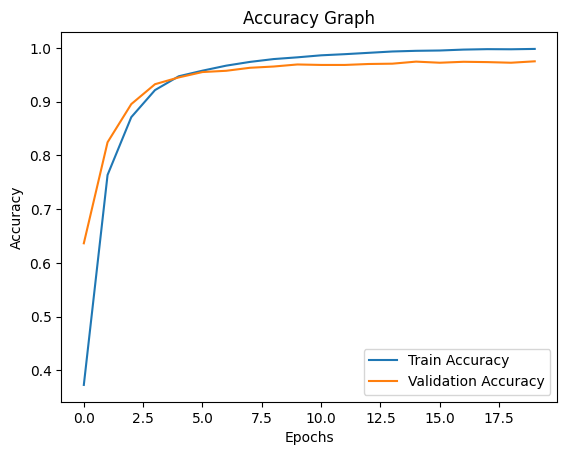

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

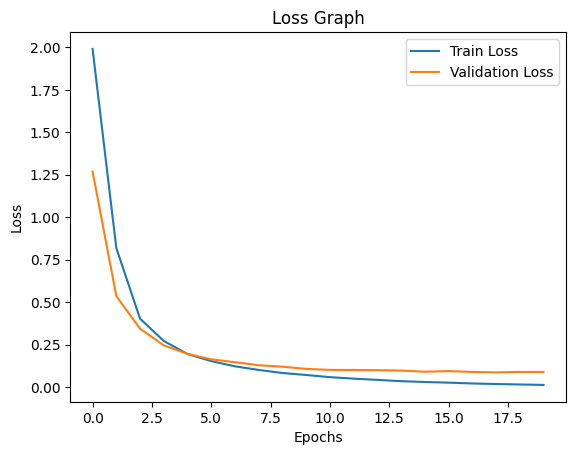

In [ ]:
# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

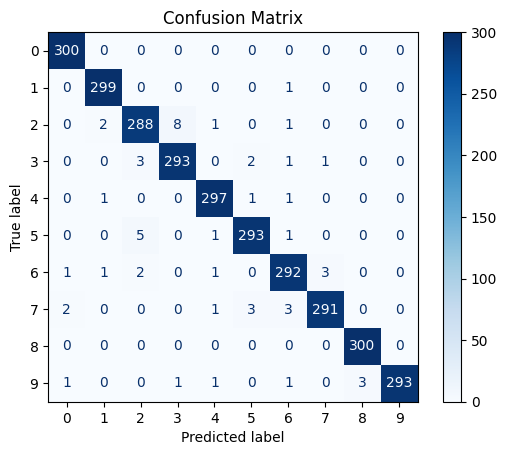

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()